In [2]:
import pandas as pd 


### SORU 1 5A SINIFINN EN BASARILI OGRENCISI

In [3]:
sinif_5A = pd.read_csv("sinif_csvleri/5A_sinifi.csv")
sinif_5B = pd.read_csv("sinif_csvleri/5B_sinifi.csv")

In [5]:
sinif_5A.columns

Index(['ogrenci_no', 'ad_soyad', 'matematik', 'turkce', 'ingilizce',
       'beden_egitimi', 'uyruk', 'sevdigi_ders'],
      dtype='object')

In [8]:
sinif_5A["not_ortalamasi"] = (sinif_5A["matematik"] + sinif_5A["turkce"]+ sinif_5A["ingilizce"] + sinif_5A["beden_egitimi"]) /4

In [15]:
sinif_5A.loc[sinif_5A["not_ortalamasi"].idxmax()]

ogrenci_no                             10
ad_soyad          Sağıt Alsoy Çamurcuoğlu
matematik                              95
turkce                                 93
ingilizce                              95
beden_egitimi                          73
uyruk                             Turkiye
sevdigi_ders                Beden Egitimi
not_ortalamasi                       89.0
Name: 9, dtype: object

### SORU 2 5B SINIFININ TURKCE NOTU EN YUKSEK OLAN OGRENCI

In [22]:
sinif_5B[sinif_5B["turkce"] == sinif_5B["turkce"].max()]

,ogrenci_no,ad_soyad,matematik,turkce,ingilizce,beden_egitimi,uyruk,sevdigi_ders
13,14,Gönen Kısakürek,46,100,46,68,Turkiye,Turkce


### SORU 3) 6A SINIFININ EN FAVORI DERSI NEDIR

In [23]:
sinif_6A = pd.read_csv("sinif_csvleri/6A_sinifi.csv")

In [35]:
sinif_6A.groupby("sevdigi_ders")["ogrenci_no"].count()

sevdigi_ders
Beden Egitimi    10
Ingilizce        12
Matematik         8
Turkce            6
Name: ogrenci_no, dtype: int64

### SORU 4) 5. SINIFLARIN EN BASARILI OGRENCISI

In [36]:
siniflar_5 = pd.concat([sinif_5A, sinif_5B], ignore_index=True)

In [40]:
en_caliskan = siniflar_5.loc[
    siniflar_5["not_ortalamasi"].idxmax()
]
en_caliskan

ogrenci_no                             10
ad_soyad          Sağıt Alsoy Çamurcuoğlu
matematik                              95
turkce                                 93
ingilizce                              95
beden_egitimi                          73
uyruk                             Turkiye
sevdigi_ders                Beden Egitimi
not_ortalamasi                       89.0
Name: 9, dtype: object

### SORU 5) 6.SINIFLARIN EN SEVILEN DERSI

In [44]:
sinif_6A["sevdigi_ders"].value_counts()

sevdigi_ders
Ingilizce        12
Beden Egitimi    10
Matematik         8
Turkce            6
Name: count, dtype: int64

### SORU 6) 7. SINIFLARIN UYRUKLARA GORE DAGILIM GRAFIGI 

In [47]:
sinif_7A = pd.read_csv("sinif_csvleri/7A_sinifi.csv")
sinif_7B = pd.read_csv("sinif_csvleri/7B_sinifi.csv")

In [48]:
siniflar_7 = pd.concat([sinif_7A, sinif_7B], ignore_index=True)

In [49]:
# Uyruk dağılımını hesapla
uyruk_dagilim = siniflar_7["uyruk"].value_counts()

<Axes: ylabel='count'>

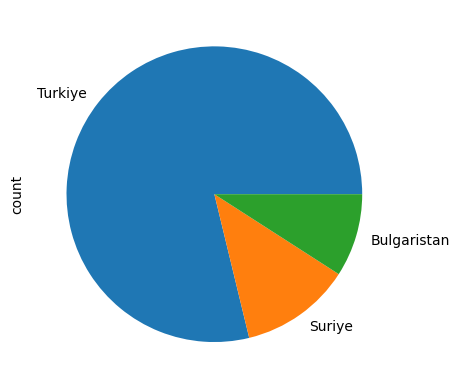

In [55]:
import matplotlib.pyplot as plt
uyruk_dagilim.plot(kind="pie")

### SORU7) OKULUN SINIFLARA GORE FAVORI DERSININ DAGILIMI

In [57]:
sinif_5A = pd.read_csv("sinif_csvleri/5A_sinifi.csv")
sinif_5B = pd.read_csv("sinif_csvleri/5B_sinifi.csv")
sinif_6A = pd.read_csv("sinif_csvleri/6A_sinifi.csv")
sinif_7A = pd.read_csv("sinif_csvleri/7A_sinifi.csv")
sinif_7B = pd.read_csv("sinif_csvleri/7B_sinifi.csv")
sinif_8A = pd.read_csv("sinif_csvleri/8A_sinifi.csv")
sinif_8B = pd.read_csv("sinif_csvleri/8B_sinifi.csv")

In [58]:
sinif_5A["sinif"] = "5A"
sinif_5B["sinif"] = "5B"
sinif_6A["sinif"] = "6A"
sinif_7A["sinif"] = "7A"
sinif_7B["sinif"] = "7B"
sinif_8A["sinif"] = "8A"
sinif_8B["sinif"] = "8B"

In [59]:
okul = pd.concat([
    sinif_5A,
    sinif_5B,
    sinif_6A,
    sinif_7A,
    sinif_7B,
    sinif_8A,
    sinif_8B
], ignore_index=True)

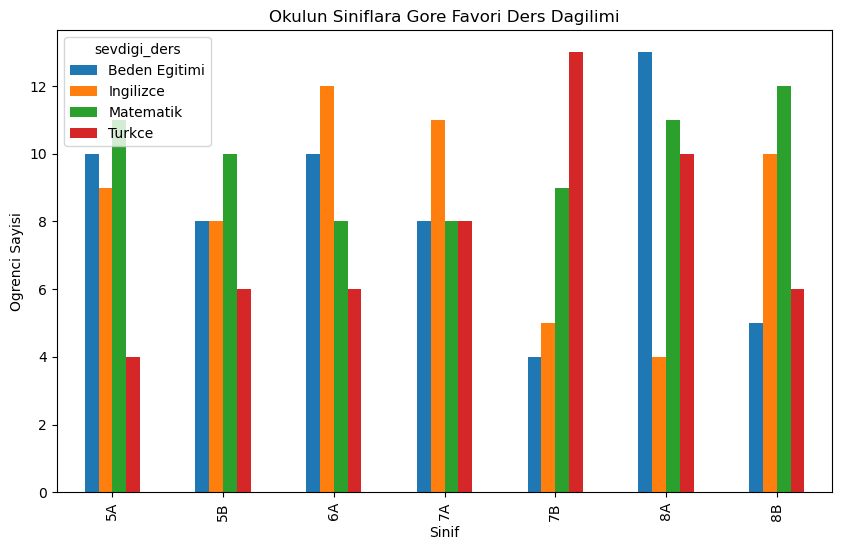

In [65]:

# Sınıflara göre favori ders dağılımı
favori_ders = okul.groupby(
    ["sinif", "sevdigi_ders"]
).size().unstack()

# Grafik çiz
favori_ders.plot(kind="bar", figsize=(10,6))

plt.title("Okulun Siniflara Gore Favori Ders Dagilimi")
plt.xlabel("Sinif")
plt.ylabel("Ogrenci Sayisi")

plt.show()

### SORU 8) OKULUN UYRUKLARA GORE DAGILIM TABLOSU

In [71]:
uyruk_tablosu = okul["uyruk"].value_counts().reset_index()

uyruk_tablosu.columns = ["uyruk", "ogrenci_sayisi"]
uyruk_tablosu

,uyruk,ogrenci_sayisi
0,Turkiye,195
1,Suriye,31
2,Bulgaristan,13


### SORU9) HER SINIFIN EN BASARILI OGRENCISININ NOT ORTALAMASI

In [73]:
okul.columns

Index(['ogrenci_no', 'ad_soyad', 'matematik', 'turkce', 'ingilizce',
       'beden_egitimi', 'uyruk', 'sevdigi_ders', 'sinif'],
      dtype='object')

In [74]:
okul["ortalama"] = (
    okul["matematik"] +
    okul["turkce"] +
    okul["ingilizce"] +
    okul["beden_egitimi"]
) / 4

In [75]:
en_basarili = okul.groupby("sinif")["ortalama"].max()


In [76]:
en_basarili

sinif
5A    89.00
5B    86.00
6A    92.25
7A    88.50
7B    90.75
8A    95.75
8B    88.50
Name: ortalama, dtype: float64